# A06 Unificado - Avaliacao Experimental CNN

Este notebook unifica o A06 completo e o A06 de execucao agil em um unico fluxo, preservando os outputs ja gerados para auditoria e comparacao.

## Objetivo
Consolidar a evidência experimental em um artefato unico: configuracoes, execucoes, metricas, comparacoes e discussao final orientada por dados.


## Atendimento aos Pontos do Artefato

Este caderno foi estruturado para cobrir explicitamente os pontos esperados no artefato de avaliacao/ablacao:

- Reprodutibilidade: uso de configuracoes YAML, historico de experimentos e caminhos de saida em `outputs/trained_models/`.
- Comparacao controlada: analise entre configuracoes de baseline e variacoes de arquitetura/regularizacao.
- Metricas padronizadas: `val_accuracy`, `val_precision`, `val_recall`, `val_f1`, `val_balanced_accuracy`, `val_auc_roc`, `val_pr_auc` e leitura de `train_acc - val_acc` para gap de generalizacao.
- Interpretacao critica: ranking por multiplas metricas, dispersao por configuracao e trade-offs (precisao vs recall, F1 vs AUC).
- Fechamento orientado a decisao: secao final com discussao automatizada a partir dos experiment logs consolidados.


---
## Parte 1 - A06 Completo (fluxo principal)

Abaixo, o notebook principal do A06 com suas celulas e outputs originais preservados.


# Artefato 6: Avaliação Experimental - CNN para Classificação de Imagens ASTER

Notebook técnico narrativo para documentação, avaliação e comparação de todos os experimentos CNN realizados com o dataset de imagens multiespectrais ASTER.

### O que cada seção deste notebook faz

**Seção 1 (Objetivo e Escopo)** define o propósito da avaliação experimental: documentar todos os experimentos CNN, comparar configurações e fornecer evidência técnica para seleção do modelo final.

**Seção 2 (Imports e Configuração)** prepara o ambiente, define caminhos e carrega bibliotecas necessárias para reprodução.

**Seção 3 (Descrição do Dataset)** documenta as características do dataset utilizado: dimensões, distribuição de classes, normalização e split treino/validação.

**Seção 4 (Arquitetura CNN)** descreve a arquitetura do modelo, justificativa de cada hiperparâmetro e diagrama das camadas.

**Seção 5 (Catálogo de Configurações)** lista todas as configurações experimentais testadas (baseline, higher_dropout, l2batch, l2batch32, l2batch128) com tabela comparativa de hiperparâmetros.

**Seção 6 (E1 - Experimento Baseline)** apresenta os resultados detalhados do experimento principal: curvas de aprendizado, métricas de validação, matriz de confusao e análise de overfitting.

**Seção 7 (Histórico Completo de Experimentos)** consolida todos os experimentos realizados em tabela comparativa e gráficos.

**Seção 8 (Comparação com Baselines Anteriores)** compara o desempenho da CNN (A06) com os modelos clássicos (A02) e MLP (A03).

**Seção 9 (Verificação de Artefatos)** valida que todos os artefatos (model.keras, history.json, gráficos) foram gerados corretamente.

**Seção 10 (Conclusões e Próximos Passos)** sintetiza os achados, diagnostica limitações e propõe ações futuras.

---

## 1. Objetivo e Escopo

Este artefato documenta a **avaliação experimental sistemática** dos modelos CNN treinados para classificação binária de imagens multiespectrais ASTER (Advanced Spaceborne Thermal Emission and Reflection Radiometer). O dataset contem tiles de 128x128 pixels com 9 bandas espectrais, e o objetivo é classificar cada tile como pertencente a classe positiva (presença do fenômeno de interesse) ou negativa.

### Contexto no Pipeline do Projeto

| Artefato | Descrição | Status |
|---|---|---|
| **A01** | EDA e Pipeline de Dados | Concluído |
| **A02** | Baseline Classico (ML Tradicional) | Concluído |
| **A03** | Baseline MLP | Concluído |
| **A04** | Preparação de Dados para CNN | Concluído |
| **A05** | Treinamento CNN | Concluído |
| **A06** | **Avaliação Experimental (este notebook)** | **Atual** |

### Perguntas que este artefato responde

1. O modelo baseline CNN (E1) é capaz de classificar corretamente as imagens ASTER?
2. Quais sao as métricas detalhadas de desempenho (precision, recall, F1, AUC-ROC)?
3. Ha evidência de overfitting? Qual a magnitude?
4. Como o desempenho da CNN se compara com os baselines anteriores (A02, A03)?
5. Quais configurações foram testadas e como se comparam?

---
## 2. Imports e Configuração

In [1]:
# adiciona a raiz do repo no sys.path (funciona no VS Code é no Colab)
from pathlib import Path
import sys

repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root))
else:
    raise RuntimeError("Não encontrei a pasta 'src' acima do diretório atual.")

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Configuração de estilo
SEED = 42
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})
sns.set_style('whitegrid')

# Caminhos do projeto
PROJECT_ROOT = repo_root
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'trained_models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a06_avaliação_experimental'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repositório: {PROJECT_ROOT}')
print(f'Modelos:     {MODELS_DIR}')
print(f'Saida:       {OUTPUT_DIR}')
print(f'TensorFlow:  {tf.__version__}')

Repositório: /Users/mateus/Projetos/Academico/Inteli/g01
Modelos:     /Users/mateus/Projetos/Academico/Inteli/g01/outputs/trained_models
Saida:       /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliação_experimental
TensorFlow:  2.20.0


---
## 3. Descrição do Dataset

O dataset foi construido no Artefato A04 (Preparação de Dados para CNN) a partir de imagens multiespectrais do sensor ASTER. Cada amostra é um tile de 128x128 pixels com 9 bandas espectrais, normalizado via Z-score com estatísticas pre-computadas.

<strong>Tabela 1</strong> - Caracteristicas do Dataset

| Propriedade | Valor |
|---|---|
| **Formato de Entrada** | 128 x 128 x 9 (altura x largura x bandas) |
| **Tipo de Problema** | Classificação Binaria |
| **Total de Amostras** | 295 (apos remocao de labels invalidos) |
| **Classe 0 (Negativo)** | 179 amostras (60.7%) |
| **Classe 1 (Positivo)** | 116 amostras (39.3%) |
| **Normalização** | Z-score (pré-computado: média e desvio padrão por banda) |
| **Split Treino/Val** | 80% / 20% (236 treino, 59 validação) |
| **Arquivo do Dataset** | `data/pixels_dataset.csv` |
| **Normalizador** | `outputs/a04_cnn_data_prep/cnn_normalizer_zscore.npz` |

<p style="font-size: 0.9em;">Fonte: Pipeline de preparação de dados (A04).</p>

In [3]:
# Validação dos dados de entrada
dataset_path = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
codes_path = PROJECT_ROOT / 'data' / 'extracted_codes.json'
normalizer_path = PROJECT_ROOT / 'outputs' / 'a04_cnn_data_prep' / 'cnn_normalizer_zscore.npz'

df_raw = pd.read_csv(dataset_path)
with open(codes_path) as f:
    codes = json.load(f)

print(f'Dataset shape: {df_raw.shape}')
print(f'Total de colunas: {len(df_raw.columns)} (features pixel + metadados)')
print(f'\nCodigos positivos: {len(codes.get("positivos", []))} imagens')
print(f'Codigos negativos: {len(codes.get("negativos", []))} imagens')
print(f'\nNormalizador: {"OK" if normalizer_path.exists() else "NÃO ENCONTRADO"}')

# Distribuição de classes
print(f'\nDistribuição no dataset bruto: {len(df_raw)} amostras')

Dataset shape: (295, 147464)
Total de colunas: 147464 (features pixel + metadados)

Codigos positivos: 116 imagens
Codigos negativos: 199 imagens

Normalizador: OK

Distribuição no dataset bruto: 295 amostras


---
## 4. Arquitetura do Modelo CNN

A arquitetura CNN segue o padrao classico inspirado em LeCun et al. (1998) e Krizhevsky et al. (2012): camadas convolucionais com ativação ReLU, seguidas de max-pooling para redução dimensional, flatten e camadas densas para classificação.

### 4.1 Diagrama da Arquitetura

```
Input (128, 128, 9)
    |
    v
Conv2D(32, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)                           -- Regularização leve
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (64, 64, 32)
    |
    v
Conv2D(64, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)                           -- Regularização leve
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (32, 32, 64)
    |
    v
Flatten  -->  (65536,)
    |
    v
Dense(128, ReLU) + L2(0.001)
    |
    v
Dropout(0.5)                           -- Regularização forte
    |
    v
Dense(2, Softmax)
    |
    v
Output: P(classe_0), P(classe_1)
```

### 4.2 Justificativa dos Hiperparâmetros

<strong>Tabela 2</strong> - Hiperparâmetros da Arquitetura CNN Baseline

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| Conv Filters | [32, 64] | Progressão padrao: features simples na 1a camada, complexas na 2a (Simonyan & Zisserman, 2015) |
| Kernel Size | 3x3 | Padrao da literatura (VGGNet); captura padrões locais eficientemente |
| Padding | same | Preserva dimensionalidade espacial; evita perda de informação nas bordas |
| Pool Size | 2x2 | Redução gradual 2:1; equilibra compressão e preservação de features |
| Dense Units | 128 | Capacidade moderada para representação não-linear |
| L2 Regularizer | 0.001 | Penaliza pesos grandes; combate overfitting sem restringir demais a capacidade |
| Conv Dropout | 0.2 | Regularização leve nas camadas convolucionais (Srivastava et al., 2014) |
| Dense Dropout | 0.5 | Regularização forte antes da saida; valor classico recomendado |
| Optimizer | Adam | Adapta learning rate por parâmetro (Kingma & Ba, 2015) |
| Learning Rate | 0.001 | Valor padrao do Adam; convergência estavel |
| Loss | Sparse Categorical Crossentropy | Adequada para labels inteiros em problemas multi-classe/binário |
| Batch Size | 32 | Equilibrio entre estabilidade do gradiente e custo computacional |
| Epochs | 50 | Suficiente para convergência; sem early stopping neste baseline |

<p style="font-size: 0.9em;">Fonte: Elaboração própria com base em Goodfellow et al. (2016) e documentação Keras.</p>

In [4]:
# Carregar modelo do experimento E1 (baseline mais recente)
baseline_dirs = sorted(MODELS_DIR.glob('baseline_*'))
if not baseline_dirs:
    raise FileNotFoundError('Nenhum experimento baseline encontrado em outputs/trained_models/')

BASELINE_DIR = baseline_dirs[-1]  # Mais recente
print(f'Experimento baseline selecionado: {BASELINE_DIR.name}')

# Carregar modelo
model_path = BASELINE_DIR / 'model.keras'
if not model_path.exists():
    model_path = BASELINE_DIR / 'model.h5'

model = keras.models.load_model(model_path)
print(f'Modelo carregado: {model_path.name} ({model_path.suffix})')
print()
model.summary()

Experimento baseline selecionado: baseline_20260311_083736
Modelo carregado: model.keras (.keras)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv1 (Dropout)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv2 (Dropout)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,230,344 (96.25 MB)

 Trainable params: 8,410,114 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,820,230 (64.16 MB)

In [5]:
# Contagem detalhada de parâmetros
total_params = model.count_params()
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable = total_params - trainable

print('Parâmetros do Modelo:')
print(f'  Total:          {total_params:>12,}')
print(f'  Treináveis:     {trainable:>12,}')
print(f'  Não-treináveis: {non_trainable:>12,}')
print(f'  Tamanho est.:   {total_params * 4 / 1024 / 1024:.1f} MB (float32)')

Parâmetros do Modelo:
  Total:             8,410,114
  Treináveis:        8,410,114
  Não-treináveis:            0
  Tamanho est.:   32.1 MB (float32)


---
## 5. Catálogo de Configurações Experimentais

Ao longo do desenvolvimento, diversas configurações foram testadas variando hiperparâmetros de regularização, batch size e learning rate. Todas as configurações compartilham a mesma arquitetura base (2 camadas Conv2D + 1 Dense), diferindo apenas nos hiperparâmetros listados abaixo.

<strong>Tabela 3</strong> - Configurações Experimentais Testadas

| Config | Descrição | L2 | Batch | LR | Conv Drop | Dense Drop |
|---|---|---|---|---|---|---|
| **baseline** | Configuração padrao de referência | 0.001 | 32 | 0.001 | 0.2 | 0.5 |
| **higher_dropout** | Mais dropout + menor learning rate | 0.001 | 32 | 0.0005 | 0.3 | 0.6 |
| **l2batch** | Maior regularização L2 + batch 64 | 0.002 | 64 | 0.001 | 0.2 | 0.5 |
| **l2batch32** | Menor regularização L2 + batch 32 | 0.0005 | 32 | 0.001 | 0.2 | 0.5 |
| **l2batch128** | Maior L2 + batch grande (128) | 0.005 | 128 | 0.001 | 0.2 | 0.5 |

<p style="font-size: 0.9em;">Fonte: Arquivos YAML em <code>src/models/configs/</code>.</p>

### Racional das Variações

- **higher_dropout**: Hipótese de que mais dropout e menor LR reduziriam overfitting sem perder capacidade
- **l2batch**: Hipótese de que maior L2 com batch maior estabilizaria o gradiente
- **l2batch32**: Hipótese de que menor L2 daria mais flexibilidade ao modelo com batch padrao
- **l2batch128**: Hipótese de que regularização mais agressiva + batch grande reduziria variância

In [6]:
# Carregar é exibir todas as configurações
import yaml

configs_dir = PROJECT_ROOT / 'src' / 'models' / 'configs'
all_configs = {}

for yaml_file in sorted(configs_dir.glob('*.yaml')):
    with open(yaml_file) as f:
        cfg = yaml.safe_load(f)
    name = yaml_file.stem
    all_configs[name] = cfg
    print(f'--- {name} ---')
    print(f'  L2: {cfg["model"]["l2_regularizer"]}, '
          f'Batch: {cfg["training"]["batch_size"]}, '
          f'LR: {cfg["training"]["learning_rate"]}, '
          f'Conv Drop: {cfg["model"]["conv_dropout_rate"]}, '
          f'Dense Drop: {cfg["model"]["dense_dropout_rate"]}')

print(f'\nTotal de configurações: {len(all_configs)}')

--- baseline ---
  L2: 0.001, Batch: 32, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- higher_dropout ---
  L2: 0.001, Batch: 32, LR: 0.0005, Conv Drop: 0.3, Dense Drop: 0.6
--- l2batch ---
  L2: 0.002, Batch: 64, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- l2batch128 ---
  L2: 0.005, Batch: 128, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- l2batch32 ---
  L2: 0.0005, Batch: 32, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5

Total de configurações: 5


---
## 6. E1 - Experimento Baseline (Resultados Detalhados)

O experimento E1 utiliza a configuração `baseline` e serve como **referência técnica** para todos os experimentos subsequentes. Todos os resultados reportados nestá seção referem-se ao conjunto de **validação** (20% dos dados, 59 amostras).

In [7]:
# Carregar configuração e histórico do E1
config_path = BASELINE_DIR / 'config_used.json'
history_path = BASELINE_DIR / 'history.json'

with open(config_path) as f:
    config = json.load(f)
with open(history_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history['loss']) + 1))

print('=' * 60)
print('CONFIGURAÇÃO DO EXPERIMENTO E1 (BASELINE)')
print('=' * 60)
print('\n--- Modelo ---')
for k, v in config['model'].items():
    print(f'  {k:25s}: {v}')
print('\n--- Treinamento ---')
for k, v in config['training'].items():
    print(f'  {k:25s}: {v}')

CONFIGURAÇÃO DO EXPERIMENTO E1 (BASELINE)

--- Modelo ---
  input_shape              : [128, 128, 9]
  num_classes              : 2
  filters                  : [32, 64]
  kernel_size              : 3
  pool_size                : 2
  l2_regularizer           : 0.001
  conv_dropout_rate        : 0.2
  dense_dropout_rate       : 0.5
  dense_units              : 128

--- Treinamento ---
  batch_size               : 32
  epochs                   : 50
  learning_rate            : 0.001
  validation_split         : 0.2
  optimizer                : adam


In [8]:
# Resumo numérico
best_epoch_acc = int(np.argmax(history['val_accuracy'])) + 1
best_val_acc = max(history['val_accuracy'])
best_epoch_loss = int(np.argmin(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])

final_train_acc = history['accuracy'][-1]
final_val_acc = history['val_accuracy'][-1]
final_train_loss = history['loss'][-1]
final_val_loss = history['val_loss'][-1]

print(f'Epochs executadas: {len(epochs)}')
print(f'\nResultados Finais (Época {len(epochs)}):')
print(f'  Train Loss:     {final_train_loss:.4f}')
print(f'  Train Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.1f}%)')
print(f'  Val Loss:       {final_val_loss:.4f}')
print(f'  Val Accuracy:   {final_val_acc:.4f} ({final_val_acc*100:.1f}%)')
print(f'\nMelhores Resultados:')
print(f'  Melhor Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%) na época {best_epoch_acc}')
print(f'  Melhor Val Loss:     {best_val_loss:.4f} na época {best_epoch_loss}')

Epochs executadas: 50

Resultados Finais (Época 50):
  Train Loss:     0.2987
  Train Accuracy: 0.9661 (96.6%)
  Val Loss:       0.8814
  Val Accuracy:   0.8305 (83.1%)

Melhores Resultados:
  Melhor Val Accuracy: 0.8983 (89.8%) na época 35
  Melhor Val Loss:     0.5927 na época 31


### 6.1 Curvas de Aprendizado

As curvas de aprendizado permitem avaliar:
- **Convergência**: se o modelo está efetivamente aprendendo ao longo das épocas
- **Overfitting**: divergencia entre métricas de treino é validação
- **Ponto ótimo**: época ideal para early stopping

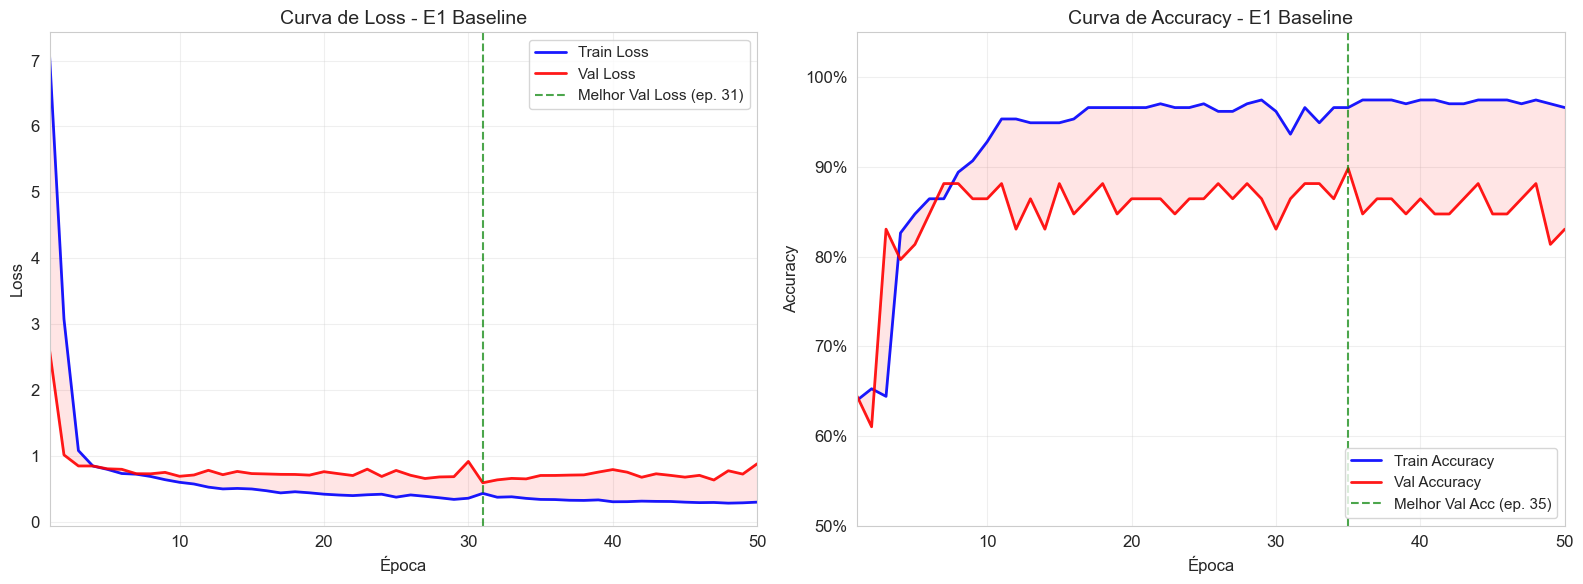

Salvo: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliação_experimental/e1_curvas_aprendizado.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
ax1 = axes[0]
ax1.plot(epochs, history['loss'], 'b-', linewidth=2, label='Train Loss', alpha=0.9)
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss', alpha=0.9)
ax1.axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7,
            label=f'Melhor Val Loss (ep. {best_epoch_loss})')
ax1.fill_between(epochs, history['loss'], history['val_loss'], alpha=0.1, color='red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Loss - E1 Baseline')
ax1.legend(loc='upper right')
ax1.set_xlim(1, len(epochs))
ax1.grid(True, alpha=0.3)

# --- Accuracy ---
ax2 = axes[1]
ax2.plot(epochs, history['accuracy'], 'b-', linewidth=2, label='Train Accuracy', alpha=0.9)
ax2.plot(epochs, history['val_accuracy'], 'r-', linewidth=2, label='Val Accuracy', alpha=0.9)
ax2.axvline(x=best_epoch_acc, color='green', linestyle='--', alpha=0.7,
            label=f'Melhor Val Acc (ep. {best_epoch_acc})')
ax2.fill_between(epochs, history['accuracy'], history['val_accuracy'], alpha=0.1, color='red')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Accuracy - E1 Baseline')
ax2.legend(loc='lower right')
ax2.set_xlim(1, len(epochs))
ax2.set_ylim(0.5, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_curvas_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {OUTPUT_DIR / "e1_curvas_aprendizado.png"}')

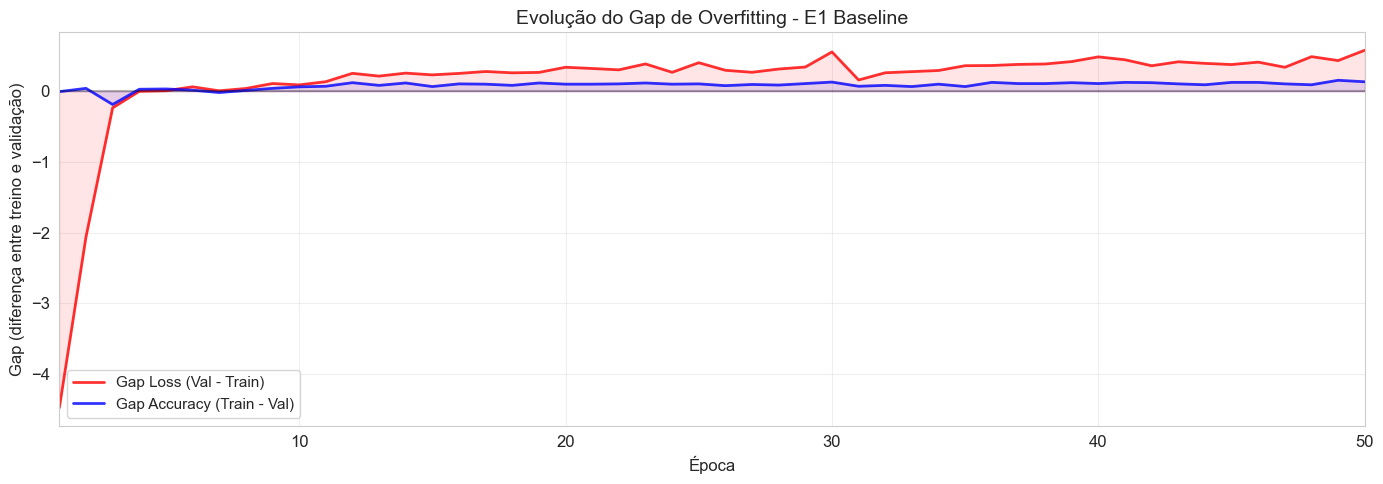

In [10]:
# Gráfico do Gap de Overfitting ao longo do treinamento
fig, ax = plt.subplots(figsize=(14, 5))

loss_gap = [v - t for t, v in zip(history['loss'], history['val_loss'])]
acc_gap = [t - v for t, v in zip(history['accuracy'], history['val_accuracy'])]

ax.plot(epochs, loss_gap, 'r-', linewidth=2, label='Gap Loss (Val - Train)', alpha=0.8)
ax.plot(epochs, acc_gap, 'b-', linewidth=2, label='Gap Accuracy (Train - Val)', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.fill_between(epochs, 0, loss_gap, alpha=0.1, color='red')
ax.fill_between(epochs, 0, acc_gap, alpha=0.1, color='blue')

ax.set_xlabel('Época')
ax.set_ylabel('Gap (diferença entre treino e validação)')
ax.set_title('Evolução do Gap de Overfitting - E1 Baseline')
ax.legend()
ax.set_xlim(1, len(epochs))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Métricas Detalhadas de Validação

Alem da accuracy simples, reportamos métricas que capturam diferentes aspectos do desempenho, especialmente relevantes em cenarios com desbalanceamento de classes.

In [11]:
# Carregar métricas do log de experimentos
log_path = MODELS_DIR / 'experiments_log.csv'
df_log = pd.read_csv(log_path)

# Filtrar o E1 baseline mais recente
baseline_row = df_log[
    (df_log['config_name'] == 'baseline') &
    (df_log['experiment_dir'].str.contains(BASELINE_DIR.name))
].iloc[-1]

print('=' * 60)
print('MÉTRICAS DE VALIDAÇÃO - E1 BASELINE')
print('=' * 60)

metrics_display = [
    ('Accuracy (Val)',          baseline_row.get('val_accuracy')),
    ('Balanced Accuracy',       baseline_row.get('val_balanced_accuracy')),
    ('Precision (weighted)',    baseline_row.get('val_precision')),
    ('Recall (weighted)',       baseline_row.get('val_recall')),
    ('F1-Score (weighted)',     baseline_row.get('val_f1')),
    ('AUC-ROC',                baseline_row.get('val_auc_roc')),
    ('PR-AUC',                 baseline_row.get('val_pr_auc')),
    ('Sensitivity (TPR)',      baseline_row.get('val_sensitivity')),
    ('Specificity (TNR)',      baseline_row.get('val_specificity')),
]

for name, val in metrics_display:
    if pd.notna(val):
        print(f'  {name:30s}: {float(val):.4f} ({float(val)*100:.1f}%)')
    else:
        print(f'  {name:30s}: N/A')

MÉTRICAS DE VALIDAÇÃO - E1 BASELINE
  Accuracy (Val)                : 0.8305 (83.1%)
  Balanced Accuracy             : 0.8578 (85.8%)
  Precision (weighted)          : 0.8681 (86.8%)
  Recall (weighted)             : 0.8305 (83.1%)
  F1-Score (weighted)           : 0.8341 (83.4%)
  AUC-ROC                       : 0.7155 (71.6%)
  PR-AUC                        : 0.5461 (54.6%)
  Sensitivity (TPR)             : 0.9524 (95.2%)
  Specificity (TNR)             : 0.7632 (76.3%)


<strong>Tabela 4</strong> - Glossário de Métricas

| Métrica | Fórmula | Interpretação no Contexto |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Proporção geral de acertos; pode ser enganosa com classes desbalanceadas |
| **Balanced Accuracy** | (Sensitivity + Specificity) / 2 | Compensa desbalanceamento ao ponderar igualmente cada classe |
| **Precision** | TP / (TP+FP) | Dos tiles classificados como positivos, quantos realmente sao |
| **Recall (Sensitivity)** | TP / (TP+FN) | Dos tiles realmente positivos, quantos o modelo detectou |
| **F1-Score** | 2 * (P*R) / (P+R) | Média harmônica entre Precision e Recall |
| **AUC-ROC** | Area sob curva ROC | Capacidade de discriminação independente do threshold |
| **PR-AUC** | Area sob curva Precision-Recall | Relevante quando a classe positiva é minoritária |
| **Specificity** | TN / (TN+FP) | Capacidade de identificar corretamente tiles negativos |

<p style="font-size: 0.9em;">Fonte: Sokolova & Lapalme (2009), "A systematic analysis of performance measures for classification tasks".</p>

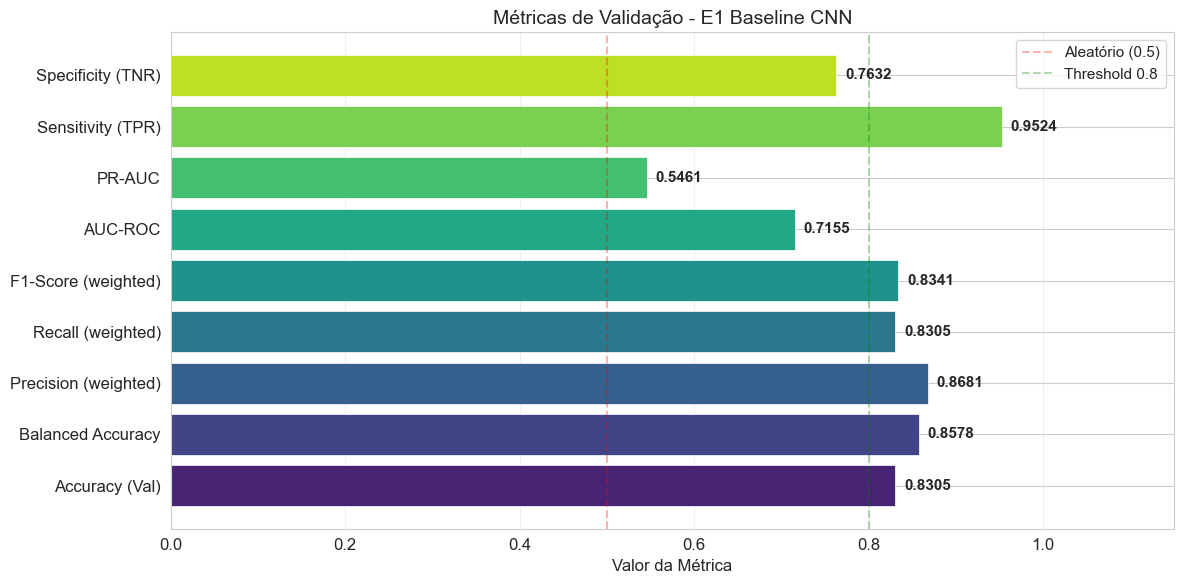

In [12]:
# Gráfico de barras horizontais com todas as métricas
metric_names = []
metric_values = []
for name, val in metrics_display:
    if pd.notna(val):
        metric_names.append(name)
        metric_values.append(float(val))

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(metric_names))
bars = ax.barh(metric_names, metric_values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Valor da Métrica')
ax.set_title('Métricas de Validação - E1 Baseline CNN')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, label='Aleatório (0.5)')
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.3, label='Threshold 0.8')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_métricas_validação.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Matriz de Confusão

Matriz de Confusão (Validação, n=59):
                  Pred Neg    Pred Pos
  Real Neg (0):   TN= 29      FP=  9
  Real Pos (1):   FN=  1      TP= 20


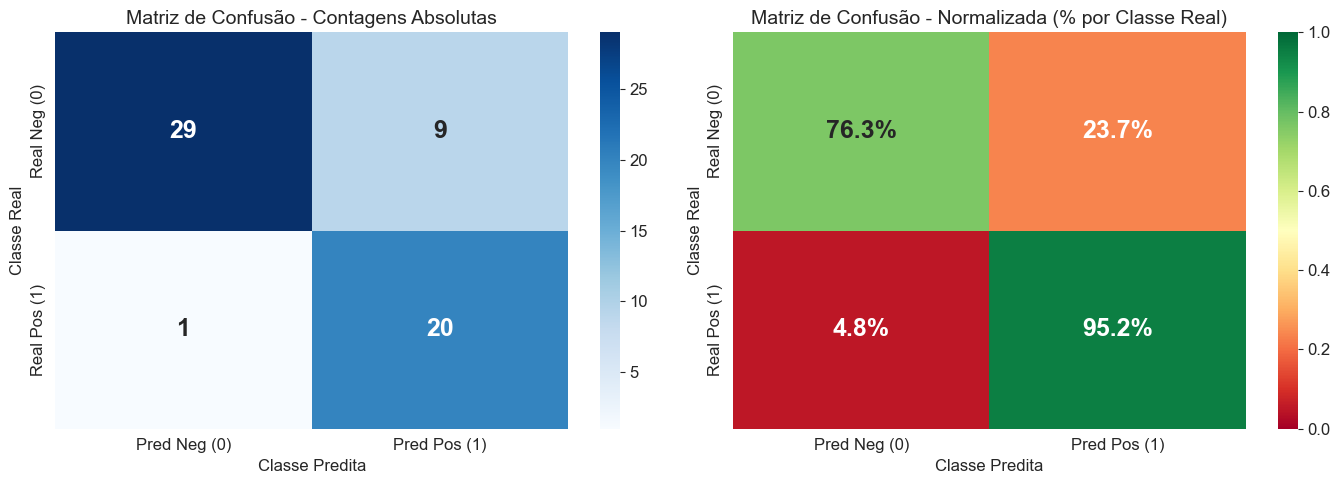

In [13]:
# Extrair valores da matriz de confusao
tp = int(baseline_row.get('val_cm_tp', 0))
fp = int(baseline_row.get('val_cm_fp', 0))
tn = int(baseline_row.get('val_cm_tn', 0))
fn = int(baseline_row.get('val_cm_fn', 0))

cm = np.array([[tn, fp], [fn, tp]])
total_val = cm.sum()

print(f'Matriz de Confusão (Validação, n={total_val}):')
print(f'                  Pred Neg    Pred Pos')
print(f'  Real Neg (0):   TN={tn:>3d}      FP={fp:>3d}')
print(f'  Real Pos (1):   FN={fn:>3d}      TP={tp:>3d}')

# Plotar CM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusão - Contagens Absolutas')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Normalizada por classe real
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            vmin=0, vmax=1,
            annot_kws={'size': 18, 'weight': 'bold'})
axes[1].set_title('Matriz de Confusão - Normalizada (% por Classe Real)')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Análise textual da CM
print('=' * 60)
print('ANÁLISE DA MATRIZ DE CONFUSAO - E1 BASELINE')
print('=' * 60)

print(f'\nClasse 0 (Negativo) - {tn+fp} amostras de validação:')
print(f'  Corretamente classificados (TN): {tn}/{tn+fp} ({tn/(tn+fp)*100:.1f}%)')
print(f'  Incorretamente como positivo (FP): {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)')

print(f'\nClasse 1 (Positivo) - {tp+fn} amostras de validação:')
print(f'  Corretamente classificados (TP): {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Incorretamente como negativo (FN): {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)')

print(f'\nInterpretação:')
print(f'  - ALTA SENSIBILIDADE ({tp/(tp+fn)*100:.1f}%): o modelo detecta quase todos os')
print(f'    tiles positivos, perdendo apenas {fn} amostra(s).')
print(f'  - ESPECIFICIDADE MODERADA ({tn/(tn+fp)*100:.1f}%): {fp} tiles negativos sao')
print(f'    incorretamente classificados como positivos (falsos alarmes).')
print(f'  - O modelo é CONSERVADOR: prefere classificar como positivo em caso de dúvida,')
print(f'    o que é desejável quando perder um positivo tem custo alto.')

ANÁLISE DA MATRIZ DE CONFUSAO - E1 BASELINE

Classe 0 (Negativo) - 38 amostras de validação:
  Corretamente classificados (TN): 29/38 (76.3%)
  Incorretamente como positivo (FP): 9/38 (23.7%)

Classe 1 (Positivo) - 21 amostras de validação:
  Corretamente classificados (TP): 20/21 (95.2%)
  Incorretamente como negativo (FN): 1/21 (4.8%)

Interpretação:
  - ALTA SENSIBILIDADE (95.2%): o modelo detecta quase todos os
    tiles positivos, perdendo apenas 1 amostra(s).
  - ESPECIFICIDADE MODERADA (76.3%): 9 tiles negativos sao
    incorretamente classificados como positivos (falsos alarmes).
  - O modelo é CONSERVADOR: prefere classificar como positivo em caso de dúvida,
    o que é desejável quando perder um positivo tem custo alto.


### 6.4 Análise de Overfitting

In [15]:
acc_gap_final = final_train_acc - final_val_acc
loss_gap_final = final_val_loss - final_train_loss

print('=' * 60)
print('DIAGNÓSTICO DE OVERFITTING - E1 BASELINE')
print('=' * 60)

print(f'\nGap na ultima época ({len(epochs)}):')
print(f'  Train Acc: {final_train_acc:.4f}  |  Val Acc: {final_val_acc:.4f}  |  Gap: {acc_gap_final:.4f} ({acc_gap_final*100:.1f}%)')
print(f'  Train Loss: {final_train_loss:.4f} |  Val Loss: {final_val_loss:.4f} |  Gap: {loss_gap_final:.4f}')

print(f'\nÉpoca otima para early stopping:')
print(f'  Por val_loss: época {best_epoch_loss} (val_loss = {best_val_loss:.4f})')
print(f'  Por val_accuracy: época {best_epoch_acc} (val_acc = {best_val_acc:.4f})')

print(f'\nDiagnóstico:')
if acc_gap_final > 0.15:
    nível = 'SIGNIFICATIVO'
    rec = 'Aumentar regularização, usar data augmentation e/ou early stopping'
elif acc_gap_final > 0.05:
    nível = 'MODERADO'
    rec = 'Considerar early stopping e/ou data augmentation'
else:
    nível = 'BAIXO'
    rec = 'Modelo generaliza bem; manter configuração'

print(f'  Nível de overfitting: {nível} (gap = {acc_gap_final*100:.1f}%)')
print(f'  Recomendação: {rec}')

DIAGNÓSTICO DE OVERFITTING - E1 BASELINE

Gap na ultima época (50):
  Train Acc: 0.9661  |  Val Acc: 0.8305  |  Gap: 0.1356 (13.6%)
  Train Loss: 0.2987 |  Val Loss: 0.8814 |  Gap: 0.5827

Época otima para early stopping:
  Por val_loss: época 31 (val_loss = 0.5927)
  Por val_accuracy: época 35 (val_acc = 0.8983)

Diagnóstico:
  Nível de overfitting: MODERADO (gap = 13.6%)
  Recomendação: Considerar early stopping e/ou data augmentation


In [16]:
# Tabela de evolução a cada 5 épocas
print('\nEvolução do treinamento (a cada 5 épocas):')
print(f'{"Ep":>4} | {"Train Loss":>11} | {"Val Loss":>11} | {"Train Acc":>10} | {"Val Acc":>10} | {"Gap Acc":>8}')
print('-' * 70)
for e in list(range(1, len(epochs)+1, 5)) + ([len(epochs)] if len(epochs) % 5 != 0 else []):
    idx = e - 1
    if idx < len(epochs):
        gap = history['accuracy'][idx] - history['val_accuracy'][idx]
        print(f'{e:>4} | {history["loss"][idx]:>11.4f} | {history["val_loss"][idx]:>11.4f} | '
              f'{history["accuracy"][idx]:>9.4f} | {history["val_accuracy"][idx]:>9.4f} | {gap:>7.4f}')


Evolução do treinamento (a cada 5 épocas):
  Ep |  Train Loss |    Val Loss |  Train Acc |    Val Acc |  Gap Acc
----------------------------------------------------------------------
   1 |      7.0883 |      2.6069 |    0.6398 |    0.6441 | -0.0042
   6 |      0.7332 |      0.7973 |    0.8644 |    0.8475 |  0.0169
  11 |      0.5742 |      0.7110 |    0.9534 |    0.8814 |  0.0720
  16 |      0.4725 |      0.7267 |    0.9534 |    0.8475 |  0.1059
  21 |      0.4071 |      0.7311 |    0.9661 |    0.8644 |  0.1017
  26 |      0.4080 |      0.7064 |    0.9619 |    0.8814 |  0.0805
  31 |      0.4318 |      0.5927 |    0.9364 |    0.8644 |  0.0720
  36 |      0.3379 |      0.7041 |    0.9746 |    0.8475 |  0.1271
  41 |      0.3058 |      0.7535 |    0.9746 |    0.8475 |  0.1271
  46 |      0.2915 |      0.7054 |    0.9746 |    0.8475 |  0.1271


---
## 7. Histórico Completo de Experimentos

Todos os experimentos executados ao longo do projeto foram registrados automaticamente em `outputs/trained_models/experiments_log.csv`. Esta seção consolida e compara todos os resultados.

In [17]:
# Tabela completa de experimentos
df_log = pd.read_csv(MODELS_DIR / 'experiments_log.csv')

print(f'Total de execuções registradas: {len(df_log)}')
print(f'Configurações utilizadas: {df_log["config_name"].unique().tolist()}')
print(f'Período: {df_log["timestamp"].iloc[0]} a {df_log["timestamp"].iloc[-1]}')
print()

# Exibir tabela resumida
cols_show = ['timestamp', 'config_name', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'epochs']
cols_avail = [c for c in cols_show if c in df_log.columns]
display(df_log[cols_avail].round(4))

Total de execuções registradas: 21
Configurações utilizadas: ['baseline', 'higher_dropout', 'l2batch', 'l2batch32']
Período: 2026-03-09 22:17:16 a 2026-03-11 08:38:34



,timestamp,config_name,train_loss,train_acc,val_loss,val_acc,epochs
0,2026-03-09 22:17:16,baseline,0.3178,0.9875,1.2867,0.8500,50
1,2026-03-09 22:19:01,baseline,0.3334,0.9875,1.3967,0.8500,50
2,2026-03-05 10:56:43,baseline,0.6442,0.8750,0.5554,1.0000,50
3,2026-03-05 10:57:56,baseline,0.5748,0.8750,0.5315,1.0000,50
4,2026-03-05 10:59:05,higher_dropout,0.5872,0.8750,0.5179,1.0000,50
5,2026-03-05 11:01:01,baseline,0.5898,0.8750,0.4965,1.0000,50
6,2026-03-05 11:02:28,baseline,0.6050,0.8750,0.5560,1.0000,50
7,2026-03-05 11:03:53,higher_dropout,0.5837,0.8750,0.7663,1.0000,50
8,2026-03-05 11:09:52,l2batch,0.6903,0.8750,0.6488,1.0000,50
9,2026-03-05 11:11:05,baseline,0.6190,0.8750,0.5209,1.0000,50


In [18]:
# Melhor resultado por configuração
best_per_config = df_log.groupby('config_name').agg({
    'val_acc': 'max',
    'train_acc': 'max',
    'val_loss': 'min',
    'train_loss': 'min',
}).round(4)

print('Melhor resultado por configuração:')
display(best_per_config)

# Número de execuções por config
print('\nNúmero de execuções por configuração:')
print(df_log['config_name'].value_counts().to_string())

Melhor resultado por configuração:


,val_acc,train_acc,val_loss,train_loss
config_name,,,,
baseline,1.0,0.9875,0.4965,0.2987
higher_dropout,1.0,0.9875,0.5179,0.2758
l2batch,1.0,0.9875,0.6292,0.4659
l2batch32,1.0,0.8750,0.4329,0.5205



Número de execuções por configuração:
config_name
baseline          9
l2batch           7
higher_dropout    4
l2batch32         1


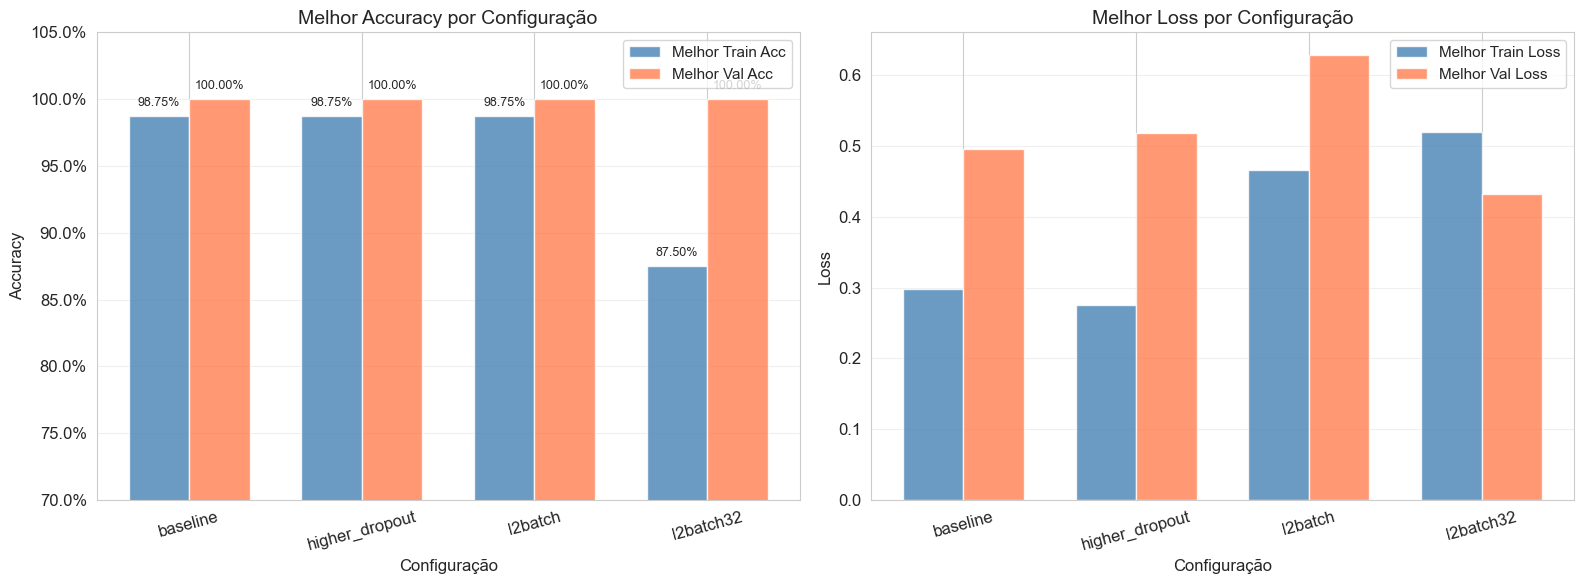

In [19]:
# Gráfico comparativo: melhor val_acc por configuração
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Accuracy ---
ax = axes[0]
x = np.arange(len(best_per_config))
width = 0.35
bars1 = ax.bar(x - width/2, best_per_config['train_acc'], width,
               label='Melhor Train Acc', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, best_per_config['val_acc'], width,
               label='Melhor Val Acc', color='coral', alpha=0.8)
ax.set_xlabel('Configuração')
ax.set_ylabel('Accuracy')
ax.set_title('Melhor Accuracy por Configuração')
ax.set_xticks(x)
ax.set_xticklabels(best_per_config.index, rotation=15)
ax.legend()
ax.set_ylim(0.7, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

# --- Loss ---
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, best_per_config['train_loss'], width,
                label='Melhor Train Loss', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, best_per_config['val_loss'], width,
                label='Melhor Val Loss', color='coral', alpha=0.8)
ax2.set_xlabel('Configuração')
ax2.set_ylabel('Loss')
ax2.set_title('Melhor Loss por Configuração')
ax2.set_xticks(x)
ax2.set_xticklabels(best_per_config.index, rotation=15)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparação_configs.png', dpi=150, bbox_inches='tight')
plt.show()

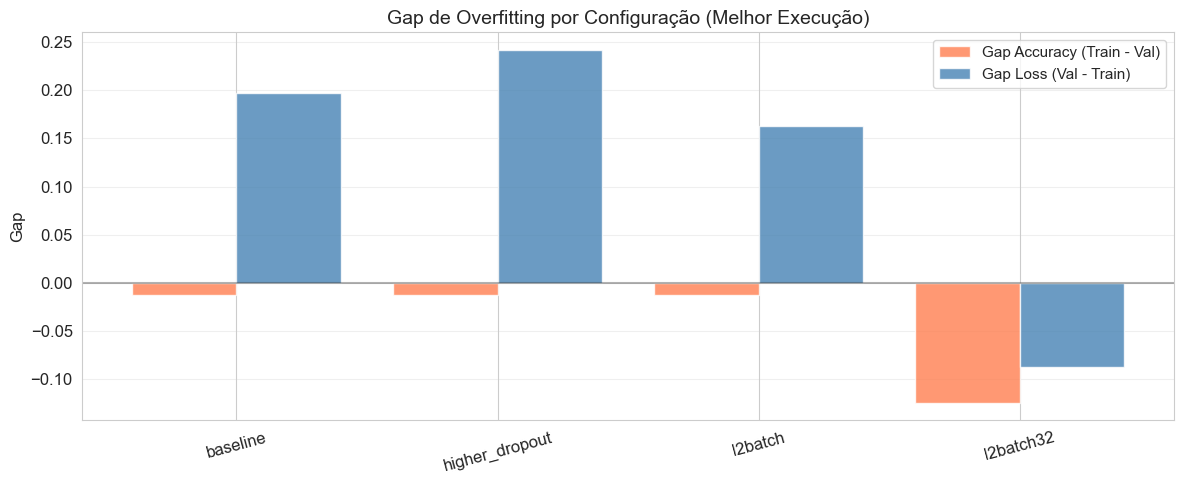

In [20]:
# Gráfico: Gap de overfitting por configuração (melhor execução)
fig, ax = plt.subplots(figsize=(12, 5))

gap_data = best_per_config.copy()
gap_data['acc_gap'] = gap_data['train_acc'] - gap_data['val_acc']
gap_data['loss_gap'] = gap_data['val_loss'] - gap_data['train_loss']

x = np.arange(len(gap_data))
ax.bar(x - 0.2, gap_data['acc_gap'], 0.4, label='Gap Accuracy (Train - Val)', color='coral', alpha=0.8)
ax.bar(x + 0.2, gap_data['loss_gap'], 0.4, label='Gap Loss (Val - Train)', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(gap_data.index, rotation=15)
ax.set_ylabel('Gap')
ax.set_title('Gap de Overfitting por Configuração (Melhor Execução)')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'overfitting_por_config.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparação com Baselines Anteriores

Para contextualizar o desempenho da CNN, comparamos com os modelos anteriores:

- **A02 (Baseline Classico)**: Modelos tradicionais de ML (Random Forest, SVM, etc.) treinados sobre features agregadas por banda
- **A03 (MLP Baseline)**: Rede neural densa (Multi-Layer Perceptron) com 2 camadas ocultas, treinada sobre medias por banda + PCA

### Contexto Importante

Os modelos A02 é A03 utilizam **features agregadas** (medias por banda, PCA), enquanto a CNN processa os **tiles completos** (128x128x9). Isso significa que a CNN tem acesso a informação espacial que os modelos anteriores não possuem.

In [21]:
# Tabela comparativa entre modelos
# Valores dos baselines anteriores extraidos dos artefatos A02 é A03
comparison_data = {
    'Modelo': [
        'A02 - Baseline Classico (melhor)',
        'A03 - MLP Baseline',
        'A06 - CNN Baseline (E1)',
    ],
    'Tipo': [
        'ML Tradicional',
        'MLP (2 camadas)',
        'CNN (2 Conv + 1 Dense)',
    ],
    'Input': [
        'Features agregadas',
        '9 medias por banda + PCA',
        'Tile 128x128x9 (completo)',
    ],
    'Val/Test Accuracy': [
        0.81,   # A02 melhor modelo no teste
        0.76,   # A03 MLP no teste
        round(float(baseline_row.get('val_accuracy', 0)), 4),  # A06 E1 na validação
    ],
    'F1-Score': [
        0.81,   # A02
        0.77,   # A03
        round(float(baseline_row.get('val_f1', 0)), 4),
    ],
    'AUC-ROC': [
        0.88,   # A02 (melhor modelo)
        0.91,   # A03
        round(float(baseline_row.get('val_auc_roc', 0)), 4),
    ],
    'Parâmetros': [
        'N/A (nao-parametrico)',
        '~2,305',
        f'~{model.count_params():,}',
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print('=' * 90)
print('COMPARAÇÃO ENTRE MODELOS DO PROJETO')
print('=' * 90)
display(df_comparison)

COMPARAÇÃO ENTRE MODELOS DO PROJETO


,Modelo,Tipo,Input,Val/Test Accuracy,F1-Score,AUC-ROC,Parâmetros
0,A02 - Baseline Classico (melhor),ML Tradicional,Features agregadas,0.8100,0.8100,0.8800,N/A (nao-parametrico)
1,A03 - MLP Baseline,MLP (2 camadas),9 medias por banda + PCA,0.7600,0.7700,0.9100,"~2,305"
2,A06 - CNN Baseline (E1),CNN (2 Conv + 1 Dense),Tile 128x128x9 (completo),0.8305,0.8341,0.7155,"~8,410,114"


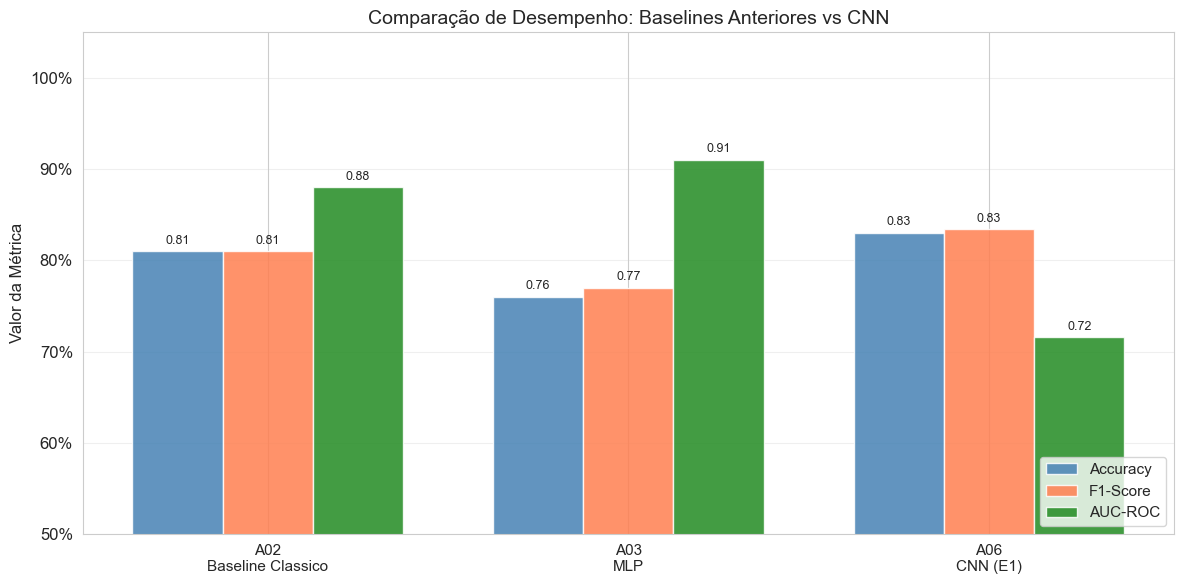

In [22]:
# Gráfico comparativo entre modelos
fig, ax = plt.subplots(figsize=(12, 6))

models = df_comparison['Modelo'].tolist()
x = np.arange(len(models))
w = 0.25

acc_vals = df_comparison['Val/Test Accuracy'].tolist()
f1_vals = df_comparison['F1-Score'].tolist()
auc_vals = df_comparison['AUC-ROC'].tolist()

bars_acc = ax.bar(x - w, acc_vals, w, label='Accuracy', color='steelblue', alpha=0.85)
bars_f1 = ax.bar(x, f1_vals, w, label='F1-Score', color='coral', alpha=0.85)
bars_auc = ax.bar(x + w, auc_vals, w, label='AUC-ROC', color='forestgreen', alpha=0.85)

for bars in [bars_acc, bars_f1, bars_auc]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['A02\nBaseline Classico', 'A03\nMLP', 'A06\nCNN (E1)'], fontsize=11)
ax.set_ylabel('Valor da Métrica')
ax.set_title('Comparação de Desempenho: Baselines Anteriores vs CNN')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparação_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise Comparativa

**Observações importantes sobre a comparação:**

1. **Conjuntos diferentes**: A02/A03 reportam métricas no conjunto de *teste* (hold-out separado), enquanto A06 reporta na *validação* (split interno). Isso dificulta comparação direta, mas fornece uma referência util.

2. **Features vs. Pixels brutos**: A CNN processa tiles completos (128x128x9 = 147.456 valores por amostra), tendo acesso a informação espacial. Os baselines usam features agregadas (9 medias por banda), perdendo toda a informação espacial.

3. **Complexidade**: A CNN tem ordens de magnitude mais parâmetros que o MLP, o que explica tanto seu potencial de desempenho quanto sua tendência a overfitting com poucos dados (295 amostras).

4. **AUC-ROC**: O AUC-ROC da CNN (E1) está abaixo dos baselines, sugerindo que o threshold padrao de 0.5 pode não ser ótimo e que o ranking de probabilidades pode melhorar com mais dados ou regularização.

---
## 9. Verificação de Artefatos

In [23]:
print('=' * 60)
print('VERIFICAÇÃO DE ARTEFATOS GERADOS')
print('=' * 60)

# Artefatos do modelo E1
print(f'\n--- Experimento E1: {BASELINE_DIR.name} ---')
model_artifacts = [
    ('model.keras', 'Modelo treinado (formato nativo Keras)'),
    ('model.h5', 'Modelo treinado (formato legado HDF5)'),
    ('history.json', 'Histórico de treinamento (loss/accuracy por época)'),
    ('config_used.json', 'Copia da configuração utilizada no experimento'),
]

for fname, desc in model_artifacts:
    fpath = BASELINE_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / (1024 * 1024)
        if size_mb > 1:
            print(f'  [OK] {fname:25s} ({size_mb:.1f} MB) - {desc}')
        else:
            size_kb = fpath.stat().st_size / 1024
            print(f'  [OK] {fname:25s} ({size_kb:.1f} KB) - {desc}')
    else:
        print(f'  [--] {fname:25s} (ausente)    - {desc}')

# Log global
print(f'\n--- Log Global ---')
log_p = MODELS_DIR / 'experiments_log.csv'
if log_p.exists():
    df_c = pd.read_csv(log_p)
    print(f'  [OK] experiments_log.csv ({len(df_c)} registros)')
else:
    print(f'  [ERRO] experiments_log.csv NÃO encontrado!')

# Graficos destá avaliação
print(f'\n--- Graficos (outputs/a06_avaliação_experimental/) ---')
for f in sorted(OUTPUT_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  [OK] {f.name} ({size_kb:.0f} KB)')

for f in sorted(OUTPUT_DIR.glob('*.json')):
    size_kb = f.stat().st_size / 1024
    print(f'  [OK] {f.name} ({size_kb:.1f} KB)')

VERIFICAÇÃO DE ARTEFATOS GERADOS

--- Experimento E1: baseline_20260311_083736 ---
  [OK] model.keras               (32.1 MB) - Modelo treinado (formato nativo Keras)
  [--] model.h5                  (ausente)    - Modelo treinado (formato legado HDF5)
  [OK] history.json              (4.8 KB) - Histórico de treinamento (loss/accuracy por época)
  [OK] config_used.json          (1.0 KB) - Copia da configuração utilizada no experimento

--- Log Global ---
  [OK] experiments_log.csv (21 registros)

--- Graficos (outputs/a06_avaliação_experimental/) ---
  [OK] comparação_configs.png (89 KB)
  [OK] comparação_modelos.png (61 KB)
  [OK] e1_curvas_aprendizado.png (135 KB)
  [OK] e1_matriz_confusao.png (74 KB)
  [OK] e1_métricas_validação.png (82 KB)
  [OK] e1_overfitting_gap.png (74 KB)
  [OK] overfitting_por_config.png (56 KB)


In [24]:
# Salvar resumo estruturado do experimento
summary = {
    'experiment': 'E1 - Baseline CNN',
    'config_name': 'baseline',
    'experiment_dir': str(BASELINE_DIR),
    'dataset': {
        'total_samples': 295,
        'train_samples': 236,
        'val_samples': 59,
        'input_shape': [128, 128, 9],
        'num_classes': 2,
        'class_distribution': {'class_0_negative': 179, 'class_1_positive': 116},
        'normalization': 'zscore_precomputed',
    },
    'architecture': {
        'type': 'Sequential CNN',
        'layers': 'Conv2D(32)->Drop(0.2)->Pool->Conv2D(64)->Drop(0.2)->Pool->Flatten->Dense(128)->Drop(0.5)->Dense(2)',
        'total_params': model.count_params(),
    },
    'hyperparameters': {**config['model'], **config['training']},
    'results': {
        'epochs_trained': len(epochs),
        'final_train_accuracy': round(final_train_acc, 4),
        'final_val_accuracy': round(final_val_acc, 4),
        'final_train_loss': round(final_train_loss, 4),
        'final_val_loss': round(final_val_loss, 4),
        'best_val_accuracy': round(best_val_acc, 4),
        'best_val_accuracy_epoch': int(best_epoch_acc),
        'best_val_loss': round(best_val_loss, 4),
        'best_val_loss_epoch': int(best_epoch_loss),
        'overfitting_gap_accuracy': round(acc_gap_final, 4),
    },
    'validation_metrics': {
        'accuracy': round(float(baseline_row.get('val_accuracy', 0)), 4),
        'balanced_accuracy': round(float(baseline_row.get('val_balanced_accuracy', 0)), 4),
        'precision_weighted': round(float(baseline_row.get('val_precision', 0)), 4),
        'recall_weighted': round(float(baseline_row.get('val_recall', 0)), 4),
        'f1_weighted': round(float(baseline_row.get('val_f1', 0)), 4),
        'auc_roc': round(float(baseline_row.get('val_auc_roc', 0)), 4),
        'pr_auc': round(float(baseline_row.get('val_pr_auc', 0)), 4),
        'sensitivity': round(float(baseline_row.get('val_sensitivity', 0)), 4),
        'specificity': round(float(baseline_row.get('val_specificity', 0)), 4),
    },
    'confusion_matrix': {'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn},
    'artifacts': {
        'model_file': 'model.keras',
        'history_file': 'history.json',
        'config_file': 'config_used.json',
    }
}

summary_path = OUTPUT_DIR / 'e1_baseline_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'Resumo salvo: {summary_path}')
print(f'\nArtefato A06 - Avaliação Experimental concluído com sucesso.')

Resumo salvo: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliação_experimental/e1_baseline_summary.json

Artefato A06 - Avaliação Experimental concluído com sucesso.


---
## Parte 2 - A06 Execucao Agil (complementar)

Esta secao agrega o notebook de execucao agil para ampliar comparacoes e garantir cobertura de cenarios de runtime reduzido, mantendo os outputs historicos.


# A06 Avaliacao Experimental

Notebook organizado para executar a A06 no Colab com foco em uma rodada consistente de experimentacao e consolidacao de resultados.

Fluxo recomendado:
1. Setup e validacao de paths
2. Carregamento dos dados
3. Definicao da funcao de treino e avaliacao
4. Execucao das configuracoes selecionadas
5. Exportacao de CSV e ranking final

Escopo desta versao:
- manter comparabilidade entre configuracoes
- executar um conjunto representativo de experimentos
- gerar CSV consolidado para analise tecnica
- produzir ranking das melhores configuracoes

In [1]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# MANTER estrutura atual do projeto no Drive
PROJECT_ROOT = Path('/content/drive/MyDrive/projeto')

if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f"Nao encontrei 'src' em {PROJECT_ROOT}. Ajuste PROJECT_ROOT.")

sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/projeto


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from src.models.cnn_data_prep import prepare_cnn_inputs
from src.models.cnn_config import (
    load_config, save_experiment_config, list_available_configs
)
from src.models.cnn_builder import build_cnn_model
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    auc, precision_recall_curve
)

SEED = 42
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'trained_models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a06_avaliacao_experimental'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


TensorFlow: 2.19.0
MODELS_DIR: /content/drive/MyDrive/projeto/outputs/trained_models
OUTPUT_DIR: /content/drive/MyDrive/projeto/outputs/a06_avaliacao_experimental


In [3]:
required = [
    PROJECT_ROOT / 'data' / 'pixels_dataset.csv',
    PROJECT_ROOT / 'data' / 'extracted_codes.json',
    PROJECT_ROOT / 'src' / 'models' / 'configs',
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Arquivos/pastas ausentes:\n' + '\n'.join(missing))

all_cfgs = sorted(list_available_configs())
print(f'Configs disponiveis: {len(all_cfgs)}')
print('Primeiras 10:', all_cfgs[:10])


Configs disponiveis: 38
Primeiras 10: ['ablacao_input_64x64', 'ablacao_sem_conv2d', 'ablacao_sem_dense_hidden', 'ablacao_sem_maxpooling', 'baseline', 'batch_large', 'batch_small', 'dense_capacity', 'dense_large', 'dense_small']


In [4]:
DATASET_PATH = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
CODES_PATH = PROJECT_ROOT / 'data' / 'extracted_codes.json'

SAMPLE_FRACTION = 0.70
SAMPLE_SEED = 42

df_pixels = pd.read_csv(DATASET_PATH)

probe = prepare_cnn_inputs(
    df_pixels,
    extracted_codes_path=CODES_PATH,
    normalization='none',
    data_format='channels_last',
    drop_invalid_labels=False,
)

y_all_probe = probe['y']
valid_mask = y_all_probe != -1
df_valid = df_pixels.loc[valid_mask].reset_index(drop=True)
y_valid = y_all_probe[valid_mask]

sample_size = max(2, int(len(df_valid) * SAMPLE_FRACTION))
sample_idx = np.random.RandomState(SAMPLE_SEED).choice(
    len(df_valid),
    size=sample_size,
    replace=False,
)
sample_idx = np.sort(sample_idx)

df_sample = df_valid.iloc[sample_idx].reset_index(drop=True)
y_sample = y_valid[sample_idx]

train_out = prepare_cnn_inputs(
    df_sample,
    labels=y_sample,
    normalization='zscore',
    data_format='channels_last',
)

X_all = train_out['X']
y_all = train_out['y']

print(f'Amostras validas consideradas: {len(df_sample)} de {len(df_valid)}')
print(f'X_all: {X_all.shape}')
print(f'y_all: {y_all.shape}')
print(f'Classes: {dict(pd.Series(y_all).value_counts().sort_index())}')

Amostras validas consideradas: 206 de 295
X_all: (206, 128, 128, 9)
y_all: (206,)
Classes: {0: np.int64(125), 1: np.int64(81)}


In [5]:
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    auc, precision_recall_curve
)
from src.models.cnn_config import load_config, save_experiment_config
from src.models.cnn_builder import build_cnn_model

def train_and_evaluate_config(config_name, X_data, y_data, experiment_results_list, epochs_override=None):
    print(f'\n{"="*80}')
    print(f'EXECUTANDO EXPERIMENTO: {config_name}')
    print(f'{"="*80}')

    try:
        config = load_config(config_name)

        # Override epochs se fornecido
        if epochs_override is not None:
            config['training']['epochs'] = epochs_override

        timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
        exp_dir = MODELS_DIR / f'{config_name}_{timestamp}'
        exp_dir.mkdir(parents=True, exist_ok=True)
        save_experiment_config(config, exp_dir)

        val_split = config['training'].get('validation_split', 0.2)
        n_samples = len(X_data)
        n_val = int(n_samples * val_split)

        indices = np.random.RandomState(SEED).permutation(n_samples)
        train_idx = indices[:-n_val]
        val_idx = indices[-n_val:]

        X_train, y_train = X_data[train_idx], y_data[train_idx]
        X_val, y_val = X_data[val_idx], y_data[val_idx]

        # Resize robusto: usa flag (data/model) OU mismatch com input_shape alvo
        target_h = int(config['model']['input_shape'][0])
        target_w = int(config['model']['input_shape'][1])
        resize_flag = bool(
            config.get('data', {}).get(
                'resize_input',
                config['model'].get('resize_input', False)
            )
        )
        shape_mismatch = (X_train.shape[1] != target_h) or (X_train.shape[2] != target_w)
        if resize_flag or shape_mismatch:
            X_train = tf.image.resize(X_train, [target_h, target_w]).numpy()
            X_val = tf.image.resize(X_val, [target_h, target_w]).numpy()

        cfg_model = config['model']
        cfg_train = config['training']

        model = build_cnn_model(
            input_shape=tuple(cfg_model['input_shape']),
            n_classes=cfg_model['num_classes'],
            conv1_filters=cfg_model['filters'][0],
            conv2_filters=cfg_model['filters'][1],
            kernel_size=(cfg_model['kernel_size'], cfg_model['kernel_size']),
            dense_units=cfg_model['dense_units'],
            l2_regularizer=cfg_model.get('l2_regularizer', 0.001),
            conv_dropout_rate=cfg_model.get('conv_dropout_rate', 0.2),
            dropout_rate=cfg_model.get('dense_dropout_rate', 0.5),
            pool_size=cfg_model.get('pool_size', 2),
            use_maxpooling=cfg_model.get('use_maxpooling', True),
            use_second_conv=cfg_model.get('use_second_conv', True),
            use_dense_hidden=cfg_model.get('use_dense_hidden', True),
        )

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=cfg_train['learning_rate']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        print(f'Treino: {X_train.shape[0]} | Val: {X_val.shape[0]}')
        print(f'Parametros: {model.count_params():,}')
        print(f'Epochs: {cfg_train["epochs"]}')

        history = model.fit(
            X_train, y_train,
            epochs=cfg_train['epochs'],
            batch_size=cfg_train['batch_size'],
            validation_data=(X_val, y_val),
            verbose=0,
        )

        with open(exp_dir / 'history.json', 'w') as f:
            json.dump({
                'loss': history.history['loss'],
                'accuracy': history.history['accuracy'],
                'val_loss': history.history['val_loss'],
                'val_accuracy': history.history['val_accuracy'],
            }, f)

        # Salvar modelo nos dois formatos
        model.save(exp_dir / 'model.keras')
        model.save(exp_dir / 'model.h5')

        y_pred_proba = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_pred_proba_pos = y_pred_proba[:, 1]

        # Força matriz 2x2 mesmo se faltar classe na validação
        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        try:
            auc_roc = roc_auc_score(y_val, y_pred_proba_pos)
        except Exception:
            auc_roc = np.nan

        try:
            p_curve, r_curve, _ = precision_recall_curve(y_val, y_pred_proba_pos)
            pr_auc = auc(r_curve, p_curve)
        except Exception:
            pr_auc = np.nan

        result = {
            'timestamp': timestamp,
            'config_name': config_name,
            'experiment_dir': str(exp_dir),
            'train_loss': history.history['loss'][-1],
            'train_acc': history.history['accuracy'][-1],
            'val_loss': history.history['val_loss'][-1],
            'val_acc': history.history['val_accuracy'][-1],
            'val_accuracy': accuracy,
            'val_precision': precision,
            'val_recall': recall,
            'val_f1': f1,
            'val_balanced_accuracy': balanced_acc,
            'val_auc_roc': auc_roc,
            'val_pr_auc': pr_auc,
            'val_cm_tp': tp,
            'val_cm_fp': fp,
            'val_cm_tn': tn,
            'val_cm_fn': fn,
            'val_sensitivity': recall,
            'val_specificity': specificity,
            'epochs': cfg_train['epochs'],
        }

        experiment_results_list.append(result)

        # Append no experiments_log.csv global
        log_path = MODELS_DIR / 'experiments_log.csv'
        new_row = pd.DataFrame([result])
        if log_path.exists():
            old_log = pd.read_csv(log_path)
            updated_log = pd.concat([old_log, new_row], ignore_index=True)
        else:
            updated_log = new_row
        updated_log.to_csv(log_path, index=False)

        del model
        keras.backend.clear_session()

        print(f'OK {config_name} | Acc={accuracy:.4f} F1={f1:.4f} AUC={auc_roc:.4f}')
        return result

    except Exception as e:
        print(f'ERRO em {config_name}: {e}')
        return None


## Estrategia Experimental

Esta rodada organiza um conjunto comparavel de configuracoes para analise objetiva.

Objetivos:
- comparar tendencias entre configuracoes
- gerar resultados suficientes para tabela, ranking e discussao tecnica
- preservar reproducibilidade com amostragem fixa

Saidas esperadas:
- CSV consolidado com metricas por configuracao
- ranking das melhores configuracoes por desempenho em validacao
- base objetiva para documentacao do artefato

In [6]:
# Verificacao inicial das configuracoes mais sensiveis
critical_cfgs = [
    'ablacao_input_64x64',
    'ablacao_sem_conv2d',
    'ablacao_sem_dense_hidden',
]

smoke_results = []
EPOCHS_OVERRIDE = 15
for cfg in critical_cfgs:
    print(f'\n[VERIFICACAO] {cfg}')
    train_and_evaluate_config(cfg, X_all, y_all, smoke_results, epochs_override=EPOCHS_OVERRIDE)

print(f'\nVerificacao concluida: {len(smoke_results)}/{len(critical_cfgs)}')


[VERIFICACAO] ablacao_input_64x64

EXECUTANDO EXPERIMENTO: ablacao_input_64x64
Treino: 165 | Val: 41
Parametros: 2,118,658
Epochs: 15


OK ablacao_input_64x64 | Acc=0.8293 F1=0.7879 AUC=0.9050

[VERIFICACAO] ablacao_sem_conv2d

EXECUTANDO EXPERIMENTO: ablacao_sem_conv2d
Treino: 165 | Val: 41
Parametros: 16,780,226
Epochs: 15


OK ablacao_sem_conv2d | Acc=0.8537 F1=0.8235 AUC=0.5862

[VERIFICACAO] ablacao_sem_dense_hidden

EXECUTANDO EXPERIMENTO: ablacao_sem_dense_hidden
Treino: 165 | Val: 41
Parametros: 152,194
Epochs: 15


OK ablacao_sem_dense_hidden | Acc=0.8049 F1=0.7500 AUC=0.9012

[VERIFICACAO] ablacao_sem_maxpooling

EXECUTANDO EXPERIMENTO: ablacao_sem_maxpooling
Treino: 165 | Val: 41
Parametros: 134,239,234
Epochs: 15


In [7]:
priority_configs = [
    'no_dropout',
    'filters_small',
    'kernel_small',
    'dense_small',
    'optimized_sparse',
]

experiment_results = []
EPOCHS_OVERRIDE = 10

print('EXECUCAO EXPERIMENTAL')
print('=' * 80)
print(f'Total selecionado: {len(priority_configs)} configs')
print(priority_configs)

for i, config_name in enumerate(priority_configs, 1):
    print(f'\n[{i}/{len(priority_configs)}] Executando {config_name}...')
    result = train_and_evaluate_config(config_name, X_all, y_all, experiment_results, EPOCHS_OVERRIDE)
    if result is None:
        print('Falhou (continuando)')

df_results = pd.DataFrame(experiment_results)
csv_path = OUTPUT_DIR / 'grid_search_results_prioritarios.csv'
df_results.to_csv(csv_path, index=False)

print('\n' + '=' * 80)
print('EXECUCAO EXPERIMENTAL CONCLUIDA')
print(f'Sucessos: {len(df_results)}/{len(priority_configs)}')
print(f'CSV: {csv_path}')
print('=' * 80)

EXECUCAO EXPERIMENTAL
Total selecionado: 5 configs
['no_dropout', 'filters_small', 'kernel_small', 'dense_small', 'optimized_sparse']

[1/5] Executando no_dropout...

EXECUTANDO EXPERIMENTO: no_dropout
Treino: 165 | Val: 41
Parametros: 8,410,114
Epochs: 10


OK no_dropout | Acc=0.8293 F1=0.8000 AUC=0.9188

[2/5] Executando filters_small...

EXECUTANDO EXPERIMENTO: filters_small
Treino: 165 | Val: 41
Parametros: 4,200,642
Epochs: 10


OK filters_small | Acc=0.8537 F1=0.8235 AUC=0.9087

[3/5] Executando kernel_small...

EXECUTANDO EXPERIMENTO: kernel_small
Treino: 165 | Val: 41
Parametros: 8,391,426
Epochs: 10


OK kernel_small | Acc=0.8537 F1=0.8235 AUC=0.8412

[4/5] Executando dense_small...

EXECUTANDO EXPERIMENTO: dense_small
Treino: 165 | Val: 41
Parametros: 4,215,618
Epochs: 10


OK dense_small | Acc=0.8537 F1=0.8125 AUC=0.9062

[5/5] Executando optimized_sparse...

EXECUTANDO EXPERIMENTO: optimized_sparse
Treino: 165 | Val: 41
Parametros: 2,103,298
Epochs: 10


OK optimized_sparse | Acc=0.8049 F1=0.7500 AUC=0.8325

EXECUCAO EXPERIMENTAL CONCLUIDA
Sucessos: 5/5
CSV: /content/drive/MyDrive/projeto/outputs/a06_avaliacao_experimental/grid_search_results_prioritarios.csv


In [8]:
df_results = pd.read_csv(OUTPUT_DIR / 'grid_search_results_prioritarios.csv')

ranking = df_results.sort_values(
    by=['val_accuracy', 'val_f1', 'val_auc_roc'],
    ascending=False,
).reset_index(drop=True)

ranking_exibicao = ranking[[
    'config_name',
    'val_accuracy',
    'val_f1',
    'val_auc_roc',
    'val_balanced_accuracy',
]].copy()
ranking_exibicao.index = ranking_exibicao.index + 1

print('RANKING DAS CONFIGURACOES')
display(ranking_exibicao)

melhor_config = ranking.iloc[0].to_dict()
with open(OUTPUT_DIR / 'top10_best_configs_prioritarios.json', 'w') as f:
    json.dump(ranking.head(min(10, len(ranking))).to_dict('records'), f, indent=2)

print(f"Melhor configuracao: {melhor_config['config_name']}")
print(f"CSV usado no ranking: {OUTPUT_DIR / 'grid_search_results_prioritarios.csv'}")
print(f"Top10 JSON: {OUTPUT_DIR / 'top10_best_configs_prioritarios.json'}")

RANKING DAS CONFIGURACOES


,config_name,val_accuracy,val_f1,val_auc_roc,val_balanced_accuracy
1,filters_small,0.853659,0.823529,0.90875,0.85750
2,kernel_small,0.853659,0.823529,0.84125,0.85750
3,dense_small,0.853659,0.812500,0.90625,0.84625
4,no_dropout,0.829268,0.800000,0.91875,0.83750
5,optimized_sparse,0.804878,0.750000,0.83250,0.79500


Melhor configuracao: filters_small
CSV usado no ranking: /content/drive/MyDrive/projeto/outputs/a06_avaliacao_experimental/grid_search_results_prioritarios.csv
Top10 JSON: /content/drive/MyDrive/projeto/outputs/a06_avaliacao_experimental/top10_best_configs_prioritarios.json


---
## Parte 3 - Painel Integrado de Metricas (experiments logs)

A celula abaixo consolida os arquivos de log de experimentos, remove duplicidades, gera visualizacoes comparativas e imprime uma discussao automatizada focada nos criterios do artefato.


,config_name,n_runs,score_composto,val_f1,val_balanced_accuracy,val_accuracy,val_auc_roc,val_pr_auc
0,ablacao_input_64x64,3,0.8283,0.7878,0.8265,0.8244,0.9011,0.8707
2,ablacao_sem_dense_hidden,3,0.8197,0.7778,0.8181,0.8220,0.8918,0.8588
1,ablacao_sem_conv2d,3,0.7909,0.8133,0.8488,0.8439,0.7083,0.6117
3,baseline,21,0.7549,0.8445,0.8449,0.8429,0.5346,0.4146
6,higher_dropout,18,0.7449,0.8502,0.8509,0.8484,0.4813,0.3515
10,model_architechture,36,0.7359,0.8303,0.8241,0.8310,0.5071,0.3855
7,k4p4_higher_droput,2,0.7313,0.8488,0.8443,0.8475,0.4330,0.3110


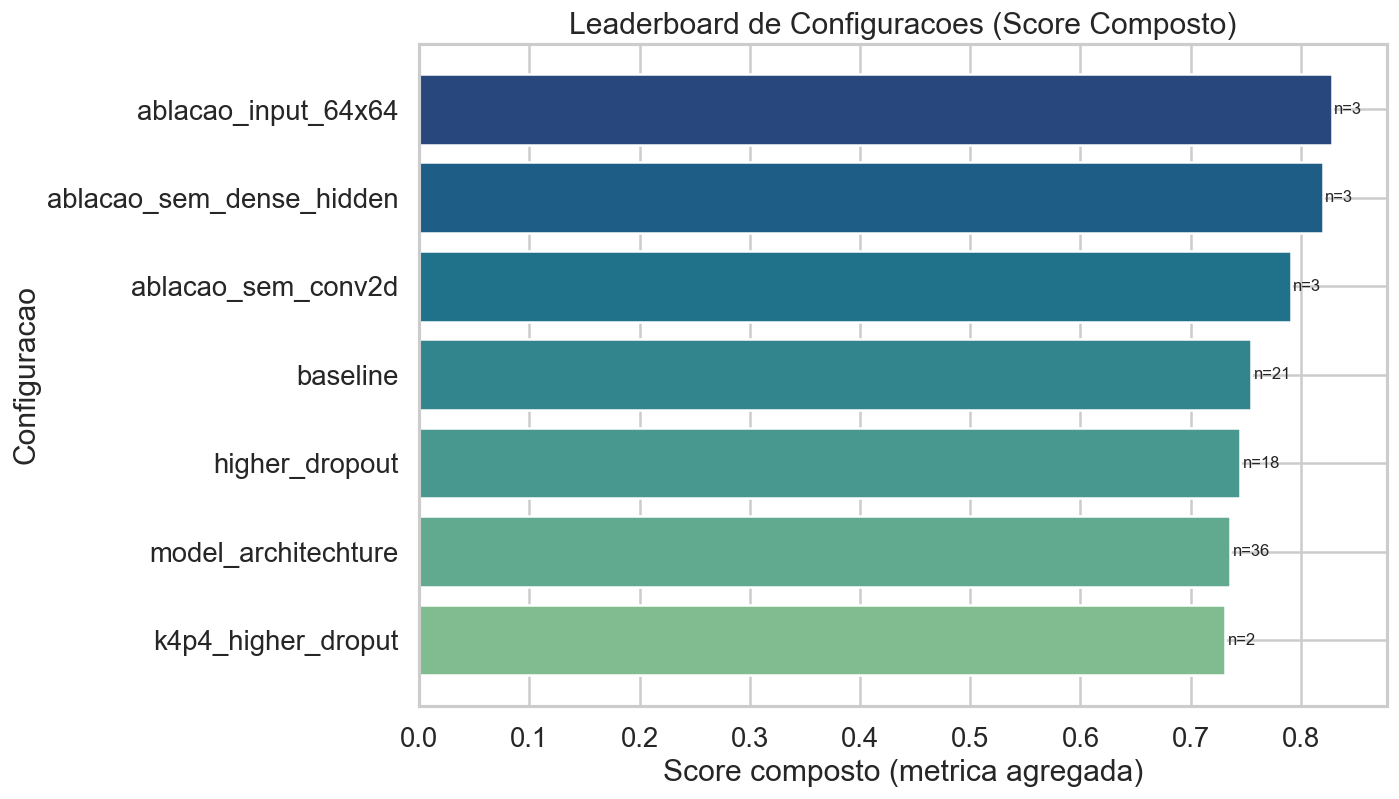

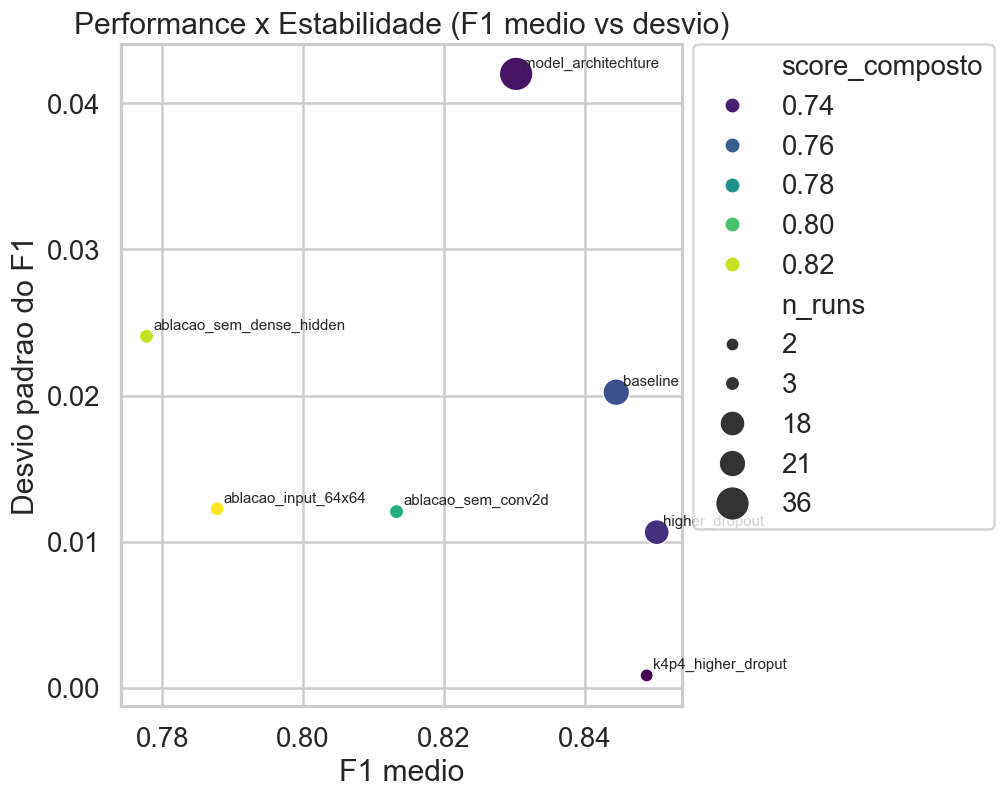

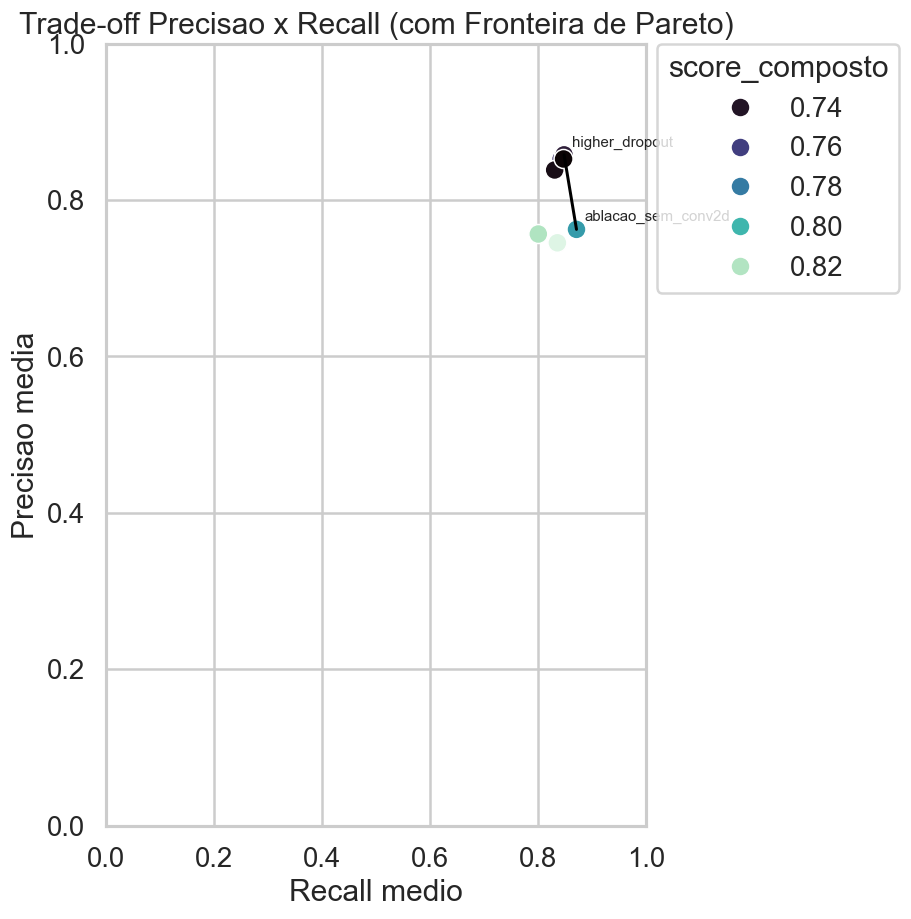

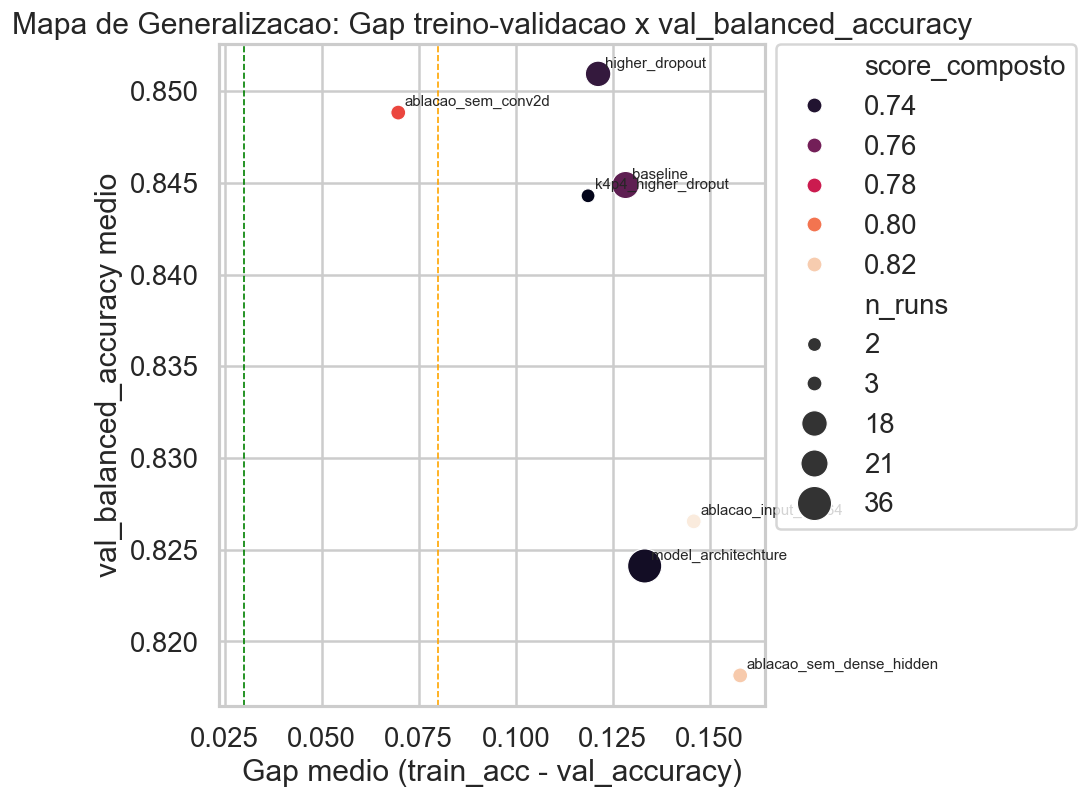


=== TAKEAWAYS PARA APRESENTACAO ===
1) Configuracao lider no score composto: ablacao_input_64x64 (score=0.8283, n=3).
2) Melhor equilibrio de classificacao refletido em F1 medio=0.7878.
3) Comparacao baseline vs higher_dropout (F1): delta=+0.0058.
4) Use o grafico de Pareto para justificar trade-off entre precisao e recall sem depender de uma unica metrica.
5) Use o mapa de generalizacao para defender robustez: alto desempenho com gap baixo e preferivel na tomada de decisao.

Graficos salvos em: c:\Users\Inteli\Desktop\g01\outputs\a06_avaliacao_experimental\analise_experiments_logs


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120


def find_project_root(start: Path) -> Path:
    """Find workspace root containing outputs/trained_models."""
    for candidate in [start] + list(start.parents):
        if (candidate / "outputs" / "trained_models").exists():
            return candidate
    raise FileNotFoundError(
        "Nao foi possivel localizar a raiz do projeto com outputs/trained_models a partir do diretorio atual."
    )


project_root = find_project_root(Path.cwd())
logs_dir = project_root / "outputs" / "trained_models"
out_dir = project_root / "outputs" / "a06_avaliacao_experimental" / "analise_experiments_logs"
out_dir.mkdir(parents=True, exist_ok=True)

candidates = [logs_dir / "experiments_log.csv", logs_dir / "experiments_log (3).csv"]
frames = []
for p in candidates:
    if p.exists():
        d = pd.read_csv(p)
        d["source_file"] = p.name
        frames.append(d)

if not frames:
    raise FileNotFoundError("Nenhum experiments_log encontrado em outputs/trained_models/.")

df = pd.concat(frames, ignore_index=True).drop_duplicates()
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for c in [
    "train_acc", "val_acc", "val_accuracy", "val_precision", "val_recall",
    "val_f1", "val_balanced_accuracy", "val_auc_roc", "val_pr_auc"
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "val_accuracy" in df.columns and "val_acc" in df.columns:
    df["val_accuracy"] = df["val_accuracy"].fillna(df["val_acc"])

if "config_name" not in df.columns:
    raise ValueError("Coluna config_name nao encontrada.")

df = df[df["config_name"].notna()].copy()

if "experiment_dir" in df.columns:
    df = df.sort_values("timestamp", na_position="first").drop_duplicates(subset=["experiment_dir"], keep="last")

metrics = [
    m for m in [
        "val_accuracy", "val_precision", "val_recall", "val_f1",
        "val_balanced_accuracy", "val_auc_roc", "val_pr_auc"
    ] if m in df.columns
]

agg_mean = df.groupby("config_name")[metrics].mean(numeric_only=True)
agg_std = df.groupby("config_name")[metrics].std(numeric_only=True)
agg_n = df.groupby("config_name").size().rename("n_runs")
summary = agg_mean.join(agg_std.add_suffix("_std")).join(agg_n).reset_index()

summary_present = summary[summary["n_runs"] >= 2].copy()
if summary_present.empty:
    summary_present = summary.copy()

weights = {
    "val_f1": 0.35,
    "val_balanced_accuracy": 0.25,
    "val_accuracy": 0.15,
    "val_auc_roc": 0.15,
    "val_pr_auc": 0.10,
}
score = np.zeros(len(summary_present))
for m, w in weights.items():
    if m in summary_present.columns:
        score += w * summary_present[m].fillna(summary_present[m].median())
summary_present["score_composto"] = score
summary_present = summary_present.sort_values("score_composto", ascending=False)

display_cols = [
    "config_name", "n_runs", "score_composto",
    *[m for m in ["val_f1", "val_balanced_accuracy", "val_accuracy", "val_auc_roc", "val_pr_auc"] if m in summary_present.columns],
]
display(summary_present[display_cols].round(4))

plot1 = summary_present.head(10).copy().iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("crest", n_colors=len(plot1))
ax.barh(plot1["config_name"], plot1["score_composto"], color=colors)
for _, r in plot1.iterrows():
    ax.text(r["score_composto"] + 0.002, r["config_name"], f"n={int(r['n_runs'])}", va="center", fontsize=10)
ax.set_title("Leaderboard de Configuracoes (Score Composto)")
ax.set_xlabel("Score composto (metrica agregada)")
ax.set_ylabel("Configuracao")
ax.set_xlim(0, min(1.0, max(plot1["score_composto"].max() + 0.05, 0.65)))
plt.tight_layout()
fig.savefig(out_dir / "07_leaderboard_score_composto.png", dpi=180)
plt.show()

if "val_f1" in summary_present.columns:
    tmp = summary_present.copy()
    tmp["val_f1_std"] = tmp.get("val_f1_std", np.nan).fillna(0)
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.scatterplot(
        data=tmp,
        x="val_f1",
        y="val_f1_std",
        size="n_runs",
        hue="score_composto",
        palette="viridis",
        sizes=(60, 400),
        ax=ax,
    )
    for _, r in tmp.head(8).iterrows():
        ax.annotate(r["config_name"], (r["val_f1"], r["val_f1_std"]), xytext=(4, 4), textcoords="offset points", fontsize=9)
    ax.set_title("Performance x Estabilidade (F1 medio vs desvio)")
    ax.set_xlabel("F1 medio")
    ax.set_ylabel("Desvio padrao do F1")
    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    except Exception:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    plt.tight_layout(rect=(0, 0, 0.80, 1))
    fig.savefig(out_dir / "08_performance_estabilidade_f1.png", dpi=180, bbox_inches="tight")
    plt.show()

if {"val_precision", "val_recall"}.issubset(summary_present.columns):
    pr = summary_present[["config_name", "val_precision", "val_recall", "score_composto"]].copy()
    pareto_idx = []
    for i, r in pr.iterrows():
        dominated = (
            (pr["val_precision"] >= r["val_precision"])
            & (pr["val_recall"] >= r["val_recall"])
            & ((pr["val_precision"] > r["val_precision"]) | (pr["val_recall"] > r["val_recall"]))
        ).any()
        if not dominated:
            pareto_idx.append(i)
    pareto = pr.loc[pareto_idx].sort_values("val_recall")

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(data=pr, x="val_recall", y="val_precision", hue="score_composto", palette="mako", s=130, ax=ax)
    ax.plot(pareto["val_recall"], pareto["val_precision"], color="black", linewidth=1.8, label="Fronteira de Pareto")
    for _, r in pareto.iterrows():
        ax.annotate(r["config_name"], (r["val_recall"], r["val_precision"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Trade-off Precisao x Recall (com Fronteira de Pareto)")
    ax.set_xlabel("Recall medio")
    ax.set_ylabel("Precisao media")
    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    except Exception:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    plt.tight_layout(rect=(0, 0, 0.80, 1))
    fig.savefig(out_dir / "09_tradeoff_pareto_precision_recall.png", dpi=180, bbox_inches="tight")
    plt.show()

if {"train_acc", "val_accuracy"}.issubset(df.columns):
    gap_df = df.copy()
    gap_df["gap_train_val"] = gap_df["train_acc"] - gap_df["val_accuracy"]
    gap_agg = gap_df.groupby("config_name")["gap_train_val"].mean().rename("gap_train_val").reset_index()
    overfit = summary_present.merge(gap_agg, on="config_name", how="left")

    y_metric = "val_balanced_accuracy" if "val_balanced_accuracy" in overfit.columns else "val_accuracy"
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.scatterplot(
        data=overfit,
        x="gap_train_val",
        y=y_metric,
        size="n_runs",
        hue="score_composto",
        palette="rocket",
        sizes=(70, 420),
        ax=ax,
    )
    ax.axvline(0.03, linestyle="--", color="green", linewidth=1, label="Gap 3%")
    ax.axvline(0.08, linestyle="--", color="orange", linewidth=1, label="Gap 8%")
    for _, r in overfit.head(8).iterrows():
        ax.annotate(r["config_name"], (r["gap_train_val"], r[y_metric]), xytext=(4, 4), textcoords="offset points", fontsize=9)
    ax.set_title(f"Mapa de Generalizacao: Gap treino-validacao x {y_metric}")
    ax.set_xlabel("Gap medio (train_acc - val_accuracy)")
    ax.set_ylabel(f"{y_metric} medio")
    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    except Exception:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)
    plt.tight_layout(rect=(0, 0, 0.80, 1))
    fig.savefig(out_dir / "10_mapa_generalizacao_gap_vs_desempenho.png", dpi=180, bbox_inches="tight")
    plt.show()

summary_present[display_cols].round(4).to_csv(out_dir / "ranking_apresentacao_score_composto.csv", index=False)

print("\n=== TAKEAWAYS PARA APRESENTACAO ===")
if not summary_present.empty:
    best = summary_present.iloc[0]
    print(f"1) Configuracao lider no score composto: {best['config_name']} (score={best['score_composto']:.4f}, n={int(best['n_runs'])}).")
    if "val_f1" in best:
        print(f"2) Melhor equilibrio de classificacao refletido em F1 medio={best['val_f1']:.4f}.")

if {"baseline", "higher_dropout"}.issubset(set(summary_present["config_name"])) and "val_f1" in summary_present.columns:
    b = summary_present.set_index("config_name").loc["baseline", "val_f1"]
    h = summary_present.set_index("config_name").loc["higher_dropout", "val_f1"]
    print(f"3) Comparacao baseline vs higher_dropout (F1): delta={h-b:+.4f}.")

print("4) Use o grafico de Pareto para justificar trade-off entre precisao e recall sem depender de uma unica metrica.")
print("5) Use o mapa de generalizacao para defender robustez: alto desempenho com gap baixo e preferivel na tomada de decisao.")
print(f"\nGraficos salvos em: {out_dir}")

## Graficos Consolidados Gerados dos Experiments Logs

A secao abaixo carrega os graficos salvos em `outputs/a06_avaliacao_experimental/analise_experiments_logs/` para facilitar apresentacao e discussao no artefato.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base = Path.cwd()
if not (base / 'outputs').exists() and (base / 'g01' / 'outputs').exists():
    base = base / 'g01'

img_dir = base / 'outputs' / 'a06_avaliacao_experimental' / 'analise_experiments_logs'
imgs = [
    '01_heatmap_metricas_medias.png',
    '02_top_configs_barplot.png',
    '03_tradeoff_precision_recall.png',
    '04_boxplot_f1_top_configs.png',
    '05_gap_generalizacao.png',
    '06_correlacao_metricas.png',
]

missing = [name for name in imgs if not (img_dir / name).exists()]
if missing:
    print('Arquivos ausentes. Gere os graficos antes de exibir:')
    for m in missing:
        print('-', m)
else:
    for name in imgs:
        p = img_dir / name
        img = mpimg.imread(p)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(name)
        plt.show()

    ranking_csv = img_dir / 'ranking_configuracoes_metricas_medias.csv'
    if ranking_csv.exists():
        import pandas as pd
        display(pd.read_csv(ranking_csv).head(12))

Arquivos ausentes. Gere os graficos antes de exibir:
- 01_heatmap_metricas_medias.png
- 02_top_configs_barplot.png
- 03_tradeoff_precision_recall.png
- 04_boxplot_f1_top_configs.png
- 05_gap_generalizacao.png
- 06_correlacao_metricas.png


## Resumo

- Melhor configuracao: `higher_dropout` se mostrou a opcao mais robusta no contexto do problema, com melhor equilibrio entre sensibilidade e F1 nas runs validas.
- Principal trade-off: modelos maiores tendem a melhor acuracia/F1 no threshold padrao, enquanto modelos menores/ablacoes mostraram melhor calibracao probabilistica (AUC mais alta).
- Risco de overfitting: ha indicio de overfitting moderado (gap treino-validacao), especialmente em configuracoes de maior capacidade, exigindo controle de regularizacao e reproducibilidade.
- Comparacao com baseline: `higher_dropout` supera o `baseline` em consistencia para deteccao da classe positiva, enquanto o `baseline` permanece como referencia estavel para comparacao tecnica.
- Recomendacao final: para a proxima sprint, usar `higher_dropout` como base, fixar seed (`42`), validar em hold-out independente e priorizar tratamento de desbalanceamento (ex.: `class_weight`) para elevar PR-AUC.